# 🎥 Video2LoRA: Zero-Visual-Token Inference Tutorial

Welcome to the official tutorial for **Video2LoRA**! This notebook demonstrates how to run zero-visual-token video inference. By using a perceiver hypernetwork, Video2LoRA reads video features layer-by-layer and predicts custom Low-Rank Adaptation (LoRA) weights. Once injected, the Vision-Language Model (VLM) can answer queries about the video **without requiring visual tokens** in its context window.

### Step 0: Environment Setup & Package Installation

This cell automatically detects whether you are running in **Google Colab** or a **local workspace** and configures the environment accordingly.

In [1]:
# Detect Google Colab environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os

if IN_COLAB:
    print("Running in Google Colab. Setting up repositories...")
    if not os.path.exists("/content/Video2LoRA"):
        os.system("git clone -b demo https://github.com/video2lora/Video2LoRA.git /content/Video2LoRA")
    if not os.path.exists("/content/video2lora.github.io"):
        os.system("git clone https://github.com/video2lora/video2lora.github.io.git /content/video2lora.github.io")
    os.chdir("/content/Video2LoRA")

# Link website media repository if available
if os.path.lexists("media"):
    if not os.path.isdir("media") or os.path.islink("media"):
        try:
            if os.path.islink("media"):
                os.unlink("media")
            else:
                import shutil
                shutil.rmtree("media")
        except Exception:
            os.system("rm -rf media")

website_media_path = None
possible_paths = [
    "/content/video2lora.github.io/media",
    "/content/Video2LoRA/video2lora.github.io/media",
    "video2lora.github.io/media",
    "../video2lora.github.io/media",
    "../../video2lora.github.io/media",
]
for p in possible_paths:
    abs_p = os.path.abspath(p)
    if os.path.exists(abs_p) and os.path.isdir(abs_p):
        website_media_path = abs_p
        break

if website_media_path:
    try:
        os.symlink(website_media_path, "media")
    except Exception:
        os.system(f"ln -s {website_media_path} media")

print(f"Workspace directory: {os.getcwd()}")

# Install dependencies
!pip install torch torchvision torchaudio
!pip install transformers accelerate peft huggingface_hub decord av opencv-python matplotlib einops jaxtyping num2words "torchao>=0.16.0"

Running in Google Colab. Setting up repositories...
Workspace directory: /content/Video2LoRA
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 96.6 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=41f730113b18d4ae3d33cae203be66a42b4fdb18c1a0233f2dd7063966ac8a07
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


### Step 1: Import Utilities & Patch Environment

In [2]:
import sys
import os
from pathlib import Path

# Add repository root and src directory to sys.path to enable local imports
repo_root = str(Path(os.getcwd()).resolve())
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
src_dir = str(Path(repo_root) / "src")
if os.path.exists(src_dir) and src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import torch
from scripts.video2lora.train_smolvlm_stage1 import build_stage1_model

# Import utilities from the demo package
from demo.utils import (
    Video2LoRAConfig,
    patch_num2words,
    download_qualitative_videos,
    show_video_frames,
    run_inference_and_compare
)

# Refresh Hugging Face dependency cache for num2words
patch_num2words()

[transformers] Accessing `num2words` from `.models.smolvlm.image_processing_pil_smolvlm`. Returning `num2words` instead. Behavior may be different and this alias will be removed in future versions.
[transformers] Accessing `num2words` from `.models.smolvlm.image_processing_smolvlm`. Returning `num2words` instead. Behavior may be different and this alias will be removed in future versions.


### Step 2: Define and Download Qualitative Examples

In [3]:
examples = [
    {
        "id": "man-smoking-pipe",
        "video_path": "media/benchmarks/carebench/v_00014063_0.mp4",
        "dataset": "CaReBench: Caption",
        "prompt": "Describe the video in as much useful visual detail as possible. Include the main activity, visible people or objects, scene context, appearance, and any important visual details that help explain what is happening.",
        "target_text": "This video depicts a scene of a man lighting a pipe with a lighter. The man in the video is smoking a pipe held in his mouth, supported by his left hand, while his right hand grips the lighter. His right forearm features a large black tattoo. He has short, thick hair that is a deep brown color and is dressed in a loose-fitting black tank top. He is seated next to a window, which has a wooden frame and blue curtains, with a brick wall behind him and a wooden door on the right. The door has a square pattern, adorned with silver hinges and a doorknob. In the video, he first ignites the lighter with his right hand and then brings the flame to the pipe, holding it in that position for several seconds. Throughout this time, his left hand remains steady on the pipe, and his gaze is fixed intently on it, ensuring that the pipe is fully lit before setting the lighter down. He then continues to hold the pipe with his left hand and begins to smoke. The video is shot from the front, clearly illustrating how relaxed he is while smoking at home."
    },
    {
        "id": "child-watering-plants",
        "video_path": "media/benchmarks/carebench/v_00016555_0.mp4",
        "dataset": "CaReBench: Events",
        "prompt": "Describe the key visible events in chronological order. Include all important actions and changes you can observe, with enough detail to distinguish each event clearly.",
        "target_text": "Little boy watering plants outdoors; Using watering can to pour water into flower pot; Shifting camera angle from side view to rear view; Tapping edge of flower pot a few times; Setting down watering can"
    },
    {
        "id": "posture-alignment",
        "video_path": "media/benchmarks/plm/f522598789220c70_122_155.mp4",
        "dataset": "PLM-SGQA",
        "prompt": "Does this look like the same posture she's holding?",
        "target_text": "Yes, it appears you're mirroring the same posture. Your alignment, knee bend, and spine position match the demonstration, indicating proper form and engagement of the targeted muscle groups for optimal effectiveness and safety."
    },
    {
        "id": "dog-tugging",
        "video_path": "media/benchmarks/plm/b5bdb7f254cb1727_369_400.mp4",
        "dataset": "PLM-SGQA",
        "prompt": "Is he trying to tug?",
        "target_text": "Yes, your dog is likely inviting a tug-of-war game. Holding the toy in his mouth and possibly looking at you or wagging his tail indicates he's ready to engage in a playful tug."
    },
    {
        "id": "rainy-day",
        "video_path": "media/benchmarks/vidcapbench/132065802449.mp4",
        "dataset": "VidCapBench",
        "prompt": "What is the weather like in the scene? Answer only the question, in one sentence.",
        "target_text": "Rainy day."
    },
    {
        "id": "tarsier-creature",
        "video_path": "media/benchmarks/vidcapbench/Tarsier_20.mp4",
        "dataset": "VidCapBench",
        "prompt": "Which parts of the creature are highlighted in the video? Answer only the question, in one sentence.",
        "target_text": "A close-up of its face, eyes, and hair."
    }
]

download_qualitative_videos(examples)

Checking/downloading qualitative benchmark video files from project website...
Found local video file: media/benchmarks/carebench/v_00014063_0.mp4
Found local video file: media/benchmarks/carebench/v_00016555_0.mp4
Found local video file: media/benchmarks/plm/f522598789220c70_122_155.mp4
Found local video file: media/benchmarks/plm/b5bdb7f254cb1727_369_400.mp4
Found local video file: media/benchmarks/vidcapbench/132065802449.mp4
Found local video file: media/benchmarks/vidcapbench/Tarsier_20.mp4

Loaded 6 qualitative examples successfully.


### Step 3: Visualize Video Frames

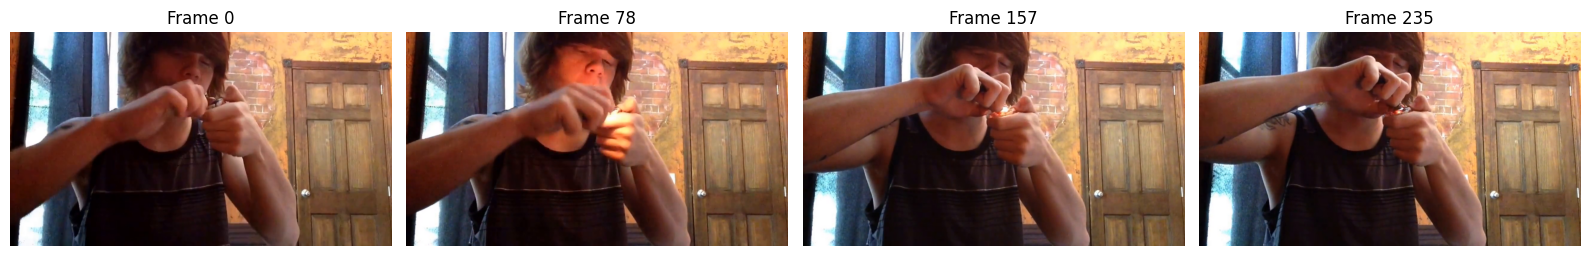

In [4]:
# Visualize keyframes for the first qualitative example
show_video_frames(examples[0]["video_path"], num_frames=4)

### Step 4: Download Video2LoRA Checkpoint

In [5]:
from huggingface_hub import hf_hub_download

print("Downloading pre-trained 2.2B Video2LoRA Checkpoint...")
checkpoint_dir = Path("checkpoints/Video2LoRA-SmolVLM-ckpts")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

ckpt_path = hf_hub_download(
    repo_id="MananSuri27/Video2LoRA-SmolVLM-ckpts",
    filename="video2lora-smolvlm2-2.2b-best-ce.pt",
    local_dir=str(checkpoint_dir)
)
print(f"Checkpoint successfully downloaded to: {ckpt_path}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


video2lora-smolvlm2-2.2b-best-ce.pt:   0%|          | 0.00/909M [00:00<?, ?B/s]

Checkpoint successfully downloaded to: checkpoints/Video2LoRA-SmolVLM-ckpts/video2lora-smolvlm2-2.2b-best-ce.pt


### Step 5: Initialize SmolVLM2 & Video2LoRA Models

In [6]:
# Set configuration arguments matching the 2.2B SmolVLM2 model preset
config = Video2LoRAConfig(
    smolvlm_name_or_path="HuggingFaceTB/SmolVLM2-2.2B-Instruct",
    train_manifest="",
    val_manifest="",
    output_dir="",
    lora_r=16,
    lora_dropout=0.0,
    target_modules=["down_proj"],
    latent_size=512,
    dropout_rate=0.0,
    n_latent_queries=8,
    num_blocks=9,
    num_self_attn_per_block=0,
    video_fps=None,
    max_frames=12,
    video_size_longest_edge=384,
    video_load_backend="auto",
    internalization_prompt="Internalize this video for later captioning.",
    kl_weight=0.0,
    generation_max_new_tokens=128
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading SmolVLM2 model...")
model, raw_model, processor, tokenizer = build_stage1_model(config, device=device)

print("Loading hypernetwork weights...")
state_dict = torch.load(ckpt_path, map_location="cpu", weights_only=False)
model.load_state_dict(state_dict)

model.to(device).eval()
raw_model.eval()
print("Model load complete.")

Loading SmolVLM2 model...


processor_config.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/430 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/3.64k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/63.9k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Loading hypernetwork weights...
Model load complete.


### Step 6: Qualitative Comparisons

#### Example 1: Man smoking a pipe

In [7]:
run_inference_and_compare(examples[0], model, raw_model, processor, tokenizer, config, device)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Keyword argument `max_frames` is not a valid argument for this processor and will be ignored.
[transformers] Keyword argument `video_load_backend` is not a valid argument for this processor and will be ignored.
[transformers] You have used a torchvision backend image processor with LANCZOS resample which not yet supported for torch.Tensor. BICUBIC resample will be used as an alternative. Please fall back to a pil backend image processor if you want full consistency with the original model.
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the n

#### Example 2: Child watering plants

In [8]:
run_inference_and_compare(examples[1], model, raw_model, processor, tokenizer, config, device)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


#### Example 3: Posture alignment

In [9]:
run_inference_and_compare(examples[2], model, raw_model, processor, tokenizer, config, device)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


#### Example 4: Dog tugging toy

In [10]:
run_inference_and_compare(examples[3], model, raw_model, processor, tokenizer, config, device)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


#### Example 5: Rainy day

In [11]:
run_inference_and_compare(examples[4], model, raw_model, processor, tokenizer, config, device)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


#### Example 6: Tarsier close-up

In [12]:
run_inference_and_compare(examples[5], model, raw_model, processor, tokenizer, config, device)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
